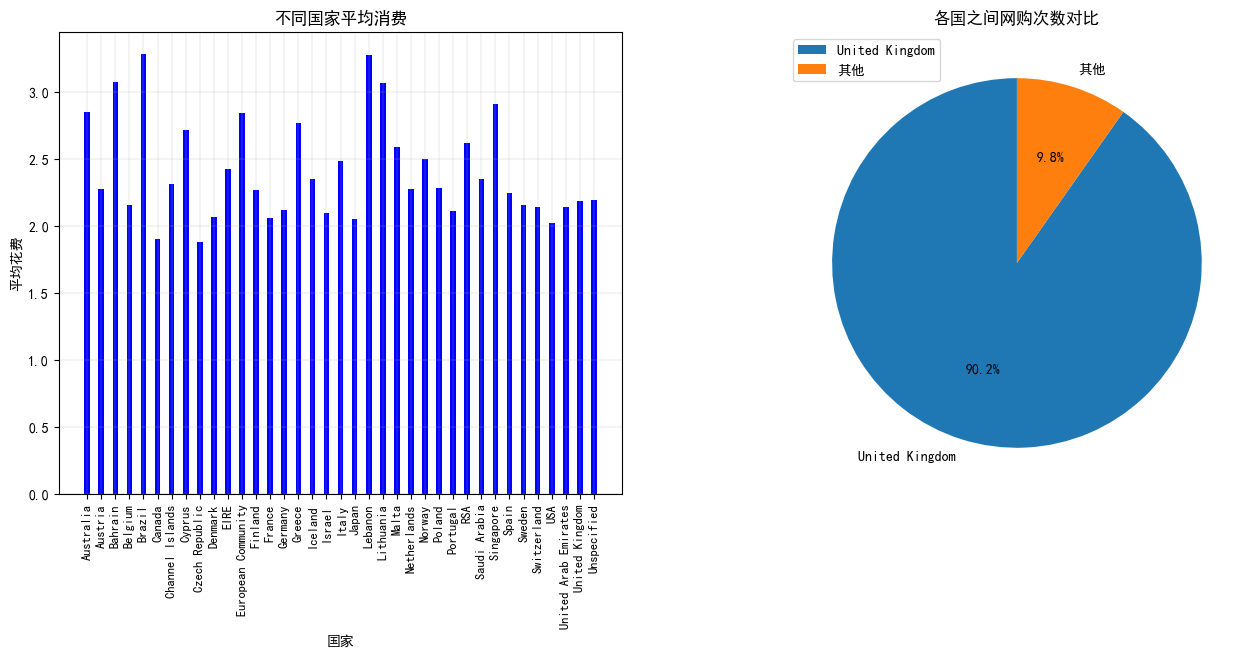

In [93]:
import matplotlib.pyplot as plt
import pandas as pd
import matplotlib
from matplotlib.pyplot import axes
from mpl_toolkits.axes_grid1.mpl_axes import Axes
plt.rcParams['font.sans-serif']=['SimHei'] #设置中文

dt=pd.read_csv('data.csv')
dt.head()#查看数据是否正常


#查找是否有缺失值
dt.isnull()
#Descripion,CustomerID有缺失值
dt=dt.dropna()#删去缺失值,避免影响后续分析
dt['CustomerID'] = dt['CustomerID'].astype(int)#浮点转为整


#查找异常值, 我是用箱线法
dt=dt.drop(dt[dt['UnitPrice']<0].index)#先去掉最不可能的值
q1=dt['UnitPrice'].quantile(0.25)#确定上1/4
q3=dt['UnitPrice'].quantile(0.75)#确定下1/4
iqr=q3-q1
upper=q3+1.5*iqr#定最大值
lower=q3-1.5*iqr#定最小值
high_out=dt[dt['UnitPrice']>upper]#超出最大值
low_out=dt[dt['UnitPrice']<lower]#低于最小值
dt=dt.drop(high_out['UnitPrice'].index)#除去异常值
dt=dt.drop(low_out['UnitPrice'].index)
dt=dt.drop(dt[dt['Quantity']<0].index)#同上
d1=dt['Quantity'].quantile(0.25)
d3=dt['Quantity'].quantile(0.75)
iqr=d3-d1
upper=d3+1.5*iqr
high_out=dt[dt['Quantity']>upper]
dt=dt.drop(high_out['Quantity'].index)


#查看日期格式
dt['InvoiceDate'].dtype
# 尝试转换日期列，错误的会变成NaT
dt['InvoiceDate_converted'] = pd.to_datetime(dt['InvoiceDate'], errors='coerce')
# 找出解析失败的行（值为NaT的）
invalid_dates = dt[dt['InvoiceDate_converted'].isna()]
invalid_dates['InvoiceDate'].head()#日期格式都正确
dt.head()


#分析
#不同国家网购花费总额和每次购买的的平均花费
c_m=dt.groupby('Country')['UnitPrice'].agg({'sum','mean'})
#不同国家网购次数
c_c=dt.groupby('Country')['Country'].count()


#可视化
#不同国家平均消费柱状图
figure,axes=plt.subplots(nrows=1,ncols=2,figsize=(16,6))#创建两张子图
axes1: Axes=axes[0]#子图一
x_countries=c_m.index.tolist()#确定x轴值
x_average_pay=c_m['mean'].tolist()#确定y轴值

axes1.bar(x_countries,x_average_pay,color='blue',width=0.4)#做出柱状图
axes1.set_title('不同国家平均消费')
axes1.set_xlabel('国家')
axes1.set_ylabel('平均花费')
axes1.tick_params(axis='x',rotation=90,labelsize=9)
axes1.grid(linestyle='-',linewidth=0.2,alpha=1)

#不同国家网购次数比例,绘制饼状图
#合并小数据(比例<5%)-->其他
axes2=axes[1]
total=c_c.sum()
large_c =c_c.loc[c_c>=total*0.05]
small_c =c_c.loc[c_c<total*0.05]

if small_c.shape[0]>0:#确保小数据存在
    large_c['其他']=small_c.sum()#将小数据合并为一种数据并入大数据

x1_countries=large_c.index.tolist()
y1_cou=large_c.values.tolist()


axes2.pie(y1_cou,labels=x1_countries,autopct='%1.1f%%',shadow=False,startangle=90)
axes2.set_title('各国之间网购次数对比')
axes2.legend()

Country
Australia                  512
Austria                    343
Bahrain                     11
Belgium                   1660
Brazil                      25
Canada                     126
Channel Islands            547
Cyprus                     486
Czech Republic              18
Denmark                    297
EIRE                      5451
European Community          47
Finland                    518
France                    6905
Germany                   7465
Greece                     125
Iceland                    166
Israel                     192
Italy                      604
Japan                      110
Lebanon                     33
Lithuania                   29
Malta                       91
Netherlands                617
Norway                     773
Poland                     253
Portugal                  1260
RSA                         46
Saudi Arabia                 9
Singapore                  151
Spain                     2046
Sweden                     250
